In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


df = pd.read_csv('dataset_horno_fusor2.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df['error'] = df['sensor_temp']-df['setpoint']


In [14]:
#Selección de variables (nada más nos deshacemos de setpoint y de las timestamps)
features = ['sensor_temp', 'error', 'gas_flow', 'air_flow', 'furnace_load', 'ambient_temp', 'energy_consumption']
X = df[features].dropna()

In [15]:
#Escalado para poder hacer PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(f'Varizanza de PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'Varianza de PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Varianza de PC3: {pca.explained_variance_ratio_[2]*100:.1f}%')

print(f'Varianza entre ambos PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

Varizanza de PC1: 48.0%
Varianza de PC2: 24.2%
Varianza de PC3: 12.8%
Varianza entre ambos PCs: 85.0%


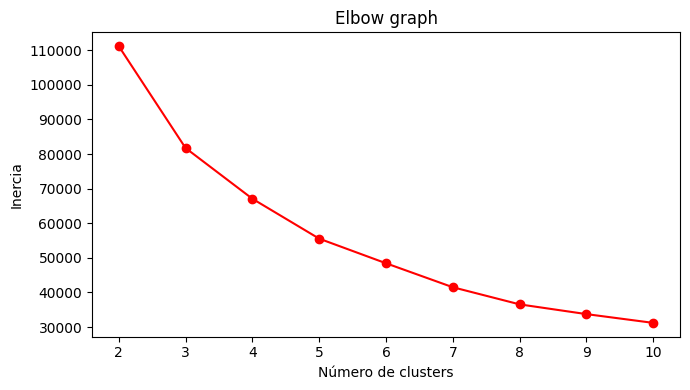

In [16]:
#Elbow graph
inercias = []
ks = range(2, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(ks, inercias, 'o-', color='r')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Elbow graph')
plt.tight_layout()

In [17]:
K = 5

km = KMeans(n_clusters=K, random_state=42, n_init=10)
df_clean = df.loc[X.index].copy()
df_clean['cluster'] = km.fit_predict(X_scaled)
df_clean['PC1'] = X_pca[:, 0]
df_clean['PC2'] = X_pca[:, 1]
df_clean['PC3'] = X_pca[:, 2]


print('Tamaño de los clusters:')
print(df_clean['cluster'].value_counts().sort_index())

Tamaño de los clusters:
cluster
0    7515
1    5421
2     292
3    6678
4     962
Name: count, dtype: int64


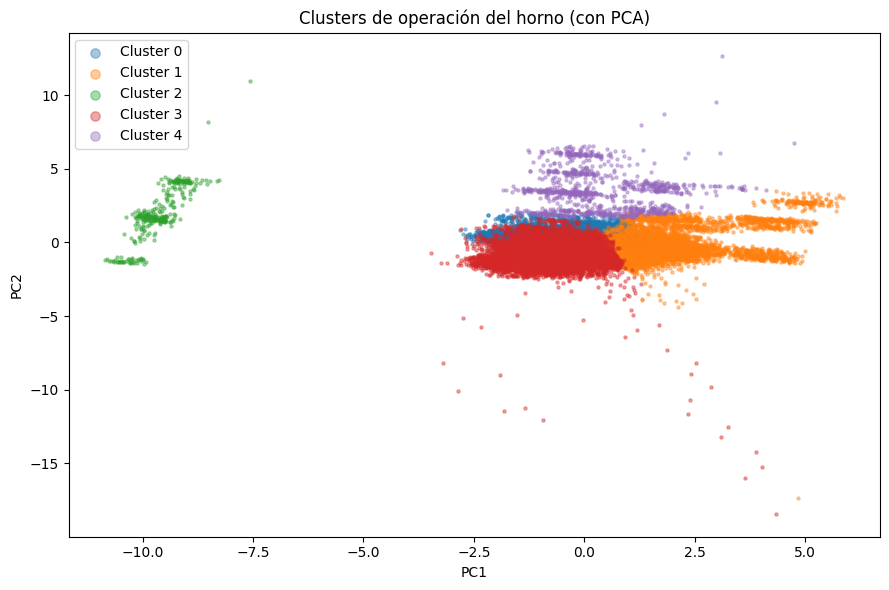

In [18]:
#Gráfica de los clusters
plt.figure(figsize=(9, 6))
for c in range(K):
    mask = df_clean['cluster'] == c
    plt.scatter(df_clean.loc[mask, 'PC1'], df_clean.loc[mask, 'PC2'],
                s=5, alpha=0.4, label=f'Cluster {c}')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters de operación del horno (con PCA)')
plt.legend(markerscale=3)
plt.tight_layout()

In [19]:
#Perfiles de los clusters
perfil = df_clean.groupby('cluster')[features].mean().round(2)
perfil

,sensor_temp,error,gas_flow,air_flow,furnace_load,ambient_temp,energy_consumption
cluster,,,,,,,
0,782.41,2.22,57.22,75.41,714.54,27.47,272.96
1,783.98,3.47,62.98,78.34,935.01,22.60,305.67
2,780.25,0.98,18.00,56.67,785.60,24.72,96.23
3,778.78,1.46,56.08,74.87,662.00,20.83,269.43
4,794.44,12.82,56.95,75.23,708.71,26.69,272.49


In [20]:
print('Silhouette:', round(silhouette_score(X_scaled, df_clean['cluster']), 4)) #Este mientras mas alto mejor (qué tan similar es cada punto a su cluster en comparación a otros clusters)
print('Davies-Bouldin:', round(davies_bouldin_score(X_scaled, df_clean['cluster']), 4)) #Este con q esté abajo de 1, y mientras más cerca de 0 mejor. (qué tan bien definidos están los clusters basados en distancias intra y entre grupos)
print('Calinski-Harabasz', round(calinski_harabasz_score(X_scaled, df_clean['cluster']), 2)) #Este no tiene mucho sentido si lo ven asi solito jsjjs sirve más para comparar entre clusters con diferentes k y este fue el más alto.

Silhouette: 0.2906
Davies-Bouldin: 0.9765
Calinski-Harabasz 8501.26


In [21]:
df['cluster'] = df_clean['cluster'].reindex(df.index)
df.head()
df

,timestamp,sensor_temp,setpoint,gas_flow,air_flow,furnace_load,ambient_temp,gas_pressure,energy_consumption,error,cluster
0,2026-02-01 00:00:00,730.005,780.000,92.446,90.584,679.274,19.064,5.023,437.501,-49.995,3.0
1,2026-02-01 00:00:20,733.535,780.001,92.446,90.584,768.807,18.913,5.007,438.777,-46.466,1.0
2,2026-02-01 00:00:40,736.839,780.002,87.769,88.591,675.378,19.801,4.985,412.699,-43.163,3.0
3,2026-02-01 00:01:00,739.829,780.003,86.147,89.818,729.407,18.340,5.018,409.782,-40.174,3.0
4,2026-02-01 00:01:20,742.579,780.005,84.413,90.456,717.542,19.761,4.972,396.238,-37.426,3.0
...,...,...,...,...,...,...,...,...,...,...,...
21595,2026-02-05 23:58:20,780.953,779.994,57.523,75.653,726.073,19.029,5.007,275.528,0.959,3.0
21596,2026-02-05 23:58:40,780.975,779.995,59.524,75.987,741.094,19.071,5.028,287.693,0.980,3.0
21597,2026-02-05 23:59:00,781.031,779.997,59.757,79.481,744.665,19.051,4.979,285.851,1.034,3.0
21598,2026-02-05 23:59:20,781.064,779.998,57.694,75.527,711.971,19.108,5.018,276.598,1.066,3.0


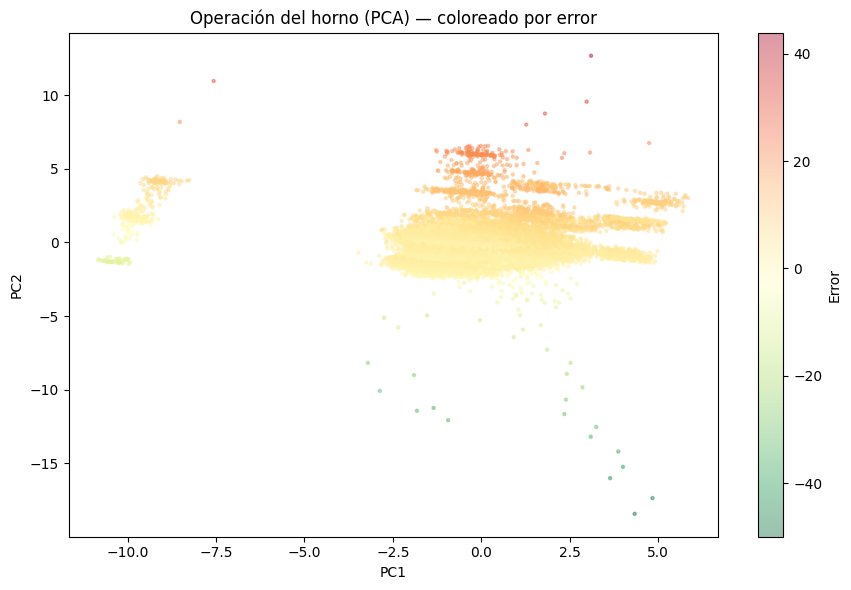

In [22]:
plt.figure(figsize=(9, 6))
sc = plt.scatter(df_clean['PC1'], df_clean['PC2'],
                 c=df_clean['error'], cmap='RdYlGn_r',
                 s=5, alpha=0.4)
plt.colorbar(sc, label='Error')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Operación del horno (PCA) — coloreado por error')
plt.tight_layout()
plt.show()

In [24]:
#Escalado para poder hacer PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(f'Varizanza de PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'Varianza de PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Varianza de PC2: {pca.explained_variance_ratio_[2]*100:.1f}%')
print(f'Varianza entre ambos PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%')

Varizanza de PC1: 48.0%
Varianza de PC2: 24.2%
Varianza de PC2: 12.8%
Varianza entre ambos PCs: 100.0%


In [25]:
n_pcs = 3
loadings = pca.components_[:n_pcs]  # shape: (3, n_features)

# Crear DataFrame de loadings
feature_names = X.columns.tolist()  # o pasa tu lista de columnas
loadings_df = pd.DataFrame(
    loadings.T,
    index=feature_names,
    columns=[f'PC{i+1}' for i in range(n_pcs)]
)

print(loadings_df.round(3))

                      PC1    PC2    PC3
sensor_temp         0.171  0.632 -0.219
error               0.130  0.642 -0.263
gas_flow            0.522 -0.128  0.074
air_flow            0.504 -0.132  0.076
furnace_load        0.394  0.044 -0.066
ambient_temp       -0.019  0.366  0.928
energy_consumption  0.522 -0.133  0.073


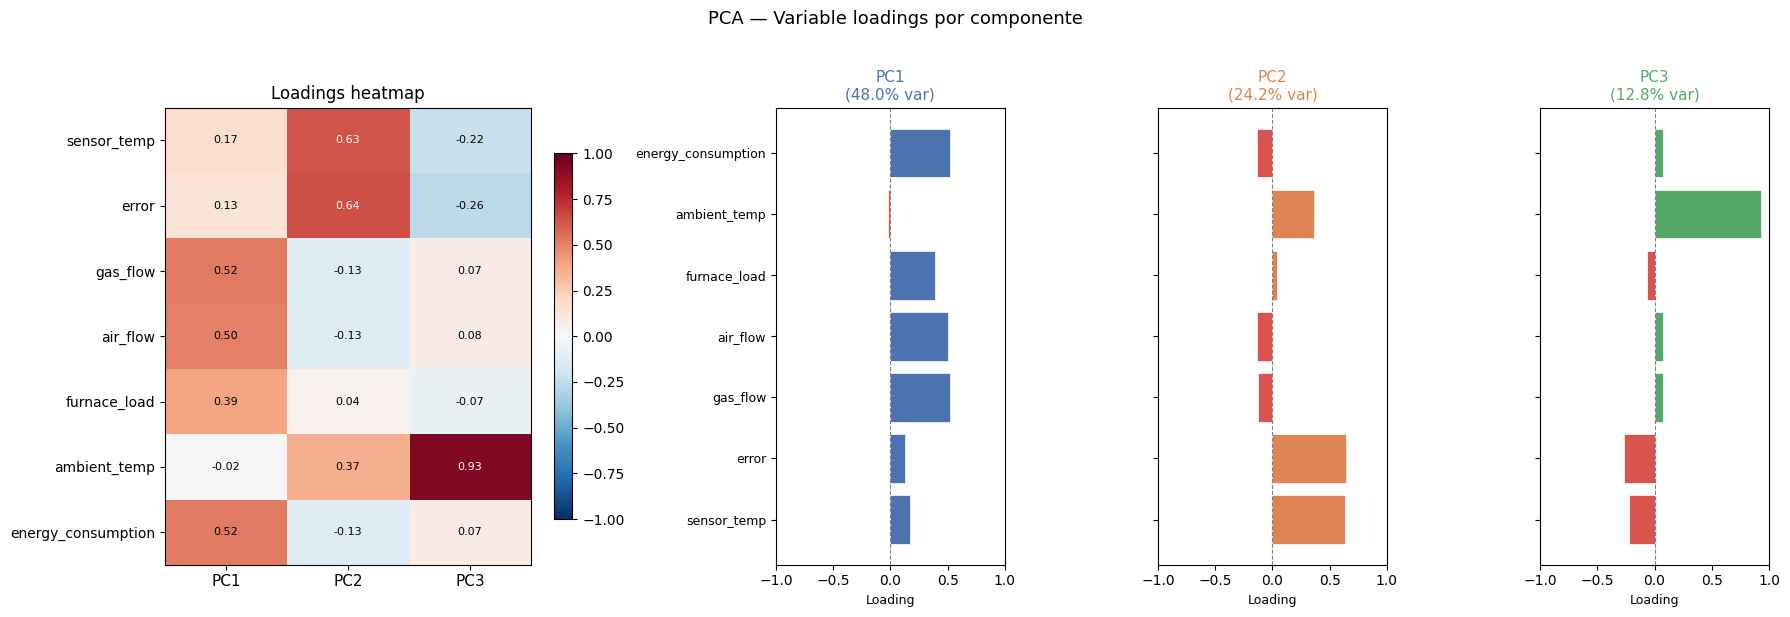

In [26]:
fig, axes = plt.subplots(1, n_pcs + 1, figsize=(18, 6),
                         gridspec_kw={'width_ratios': [2] + [1]*n_pcs})

# --- Heatmap ---
ax = axes[0]
im = ax.imshow(loadings_df.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(n_pcs))
ax.set_xticklabels(loadings_df.columns, fontsize=11)
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names, fontsize=10)
ax.set_title('Loadings heatmap', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8)

# Anotar valores
for i in range(len(feature_names)):
    for j in range(n_pcs):
        val = loadings_df.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color='black' if abs(val) < 0.6 else 'white')

# --- Barras por PC ---
colors = ['#4C72B0', '#DD8452', '#55A868']
for k in range(n_pcs):
    ax = axes[k + 1]
    vals = loadings_df[f'PC{k+1}']
    bar_colors = [colors[k] if v >= 0 else '#d9534f' for v in vals]
    ax.barh(feature_names, vals, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_xlim(-1, 1)
    ax.set_title(f'PC{k+1}\n({pca.explained_variance_ratio_[k]*100:.1f}% var)',
                 fontsize=11, color=colors[k])
    ax.tick_params(axis='y', labelsize=9)
    ax.set_xlabel('Loading', fontsize=9)
    if k > 0:
        ax.set_yticklabels([])

plt.suptitle('PCA — Variable loadings por componente', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()